<a href="https://colab.research.google.com/github/majorquev/DBDC_202604_Programacion_en_R_para_ciencia_de_datos/blob/main/Clases/Clase5/00_Ejemplos_adicionales_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejemplos adicionales ggplot2

**Autor:** Miguel Jorquera Viguera.<br>
**E-mail:** majorquev@gmail.com<br>
**Ayudante:** Rodrigo Morales<br>
**E-mail ayudante:** rumorale1@gmail.com

In [2]:
#install.packages("nycflights13")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(ggplot2)
library(dplyr)
library(nycflights13)


## `stat_bin()`: Permite generar bines en la data y visualizar etiquetas entre otros elementos

1.- Creamos un histograma con 10 bins, y visualizaremos los conteos en etiquetas sobre cada barra del histograma. Para ello considerar a función `stat_bin` con parámetros `geom = 'label'`, y `mapping = aes(label=..count..)`.

In [4]:
library(ggplot2)
library(dplyr)
# Histograma de frecuencias absolutas con R base.
set.seed(15)
data <- data.frame(x = rnorm(1000))






In [5]:
head(data)

,x
,<dbl>
1,0.2588229
2,1.8311207
3,-0.3396186
4,0.8971982
5,0.4880163
6,-1.2553858


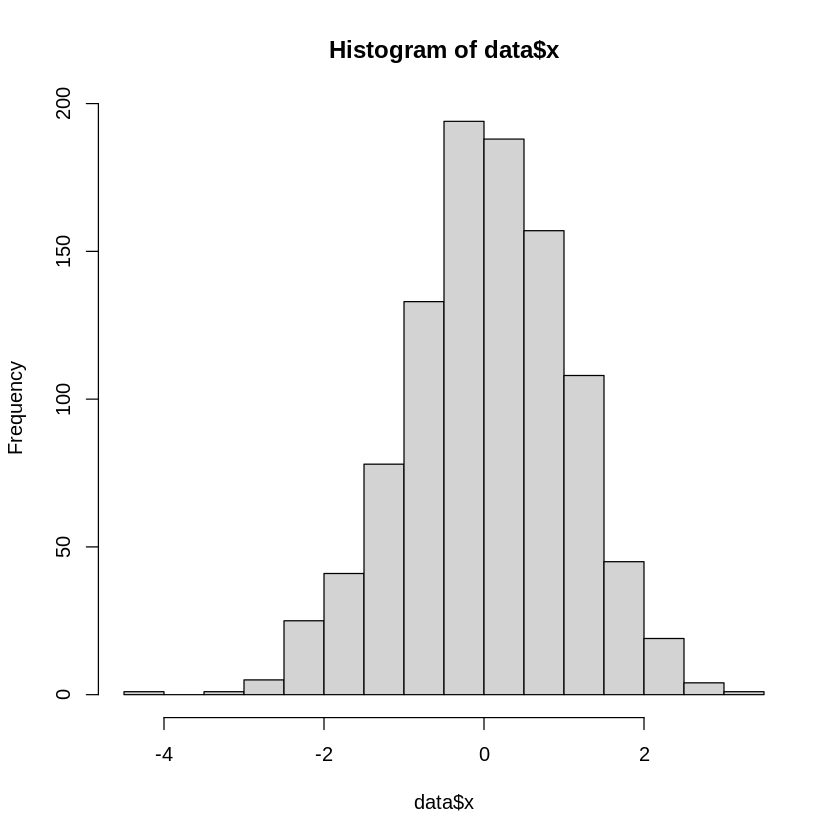

In [8]:
hist(data$x, freq = T)

2.- Misma Visualización pero con Ggplot2 y etiquetas con `stat_bin()` y `geom = label`

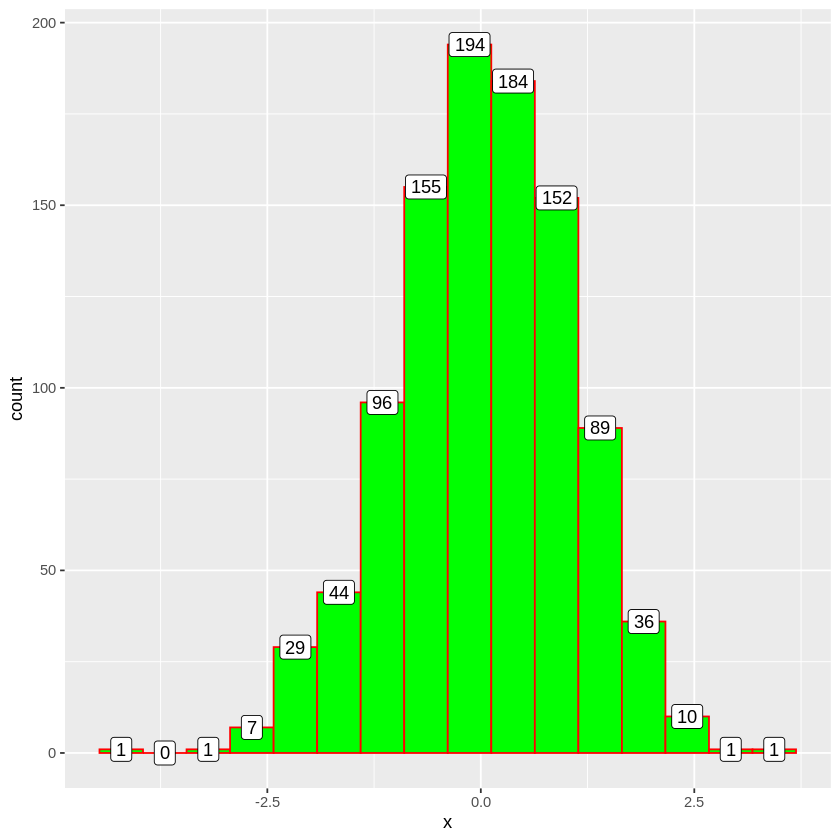

In [14]:
## ggplot2
## frecuencias absolutas (conteos)
data %>%
  ggplot() +
  aes(x = x) +
  geom_histogram(
    bins = 16,
    fill = "green",
    color = "red"
  ) +
  stat_bin(
    bins = 16,
    geom = "label",
    mapping = aes(label = after_stat(count))
  )

3.- Histograma de densidades, mismas visualizaciones.
 > Recordar: [Tipos de histogramas](https://math.stackexchange.com/questions/2666834/what-is-the-difference-between-frequency-and-density-in-a-histogram)



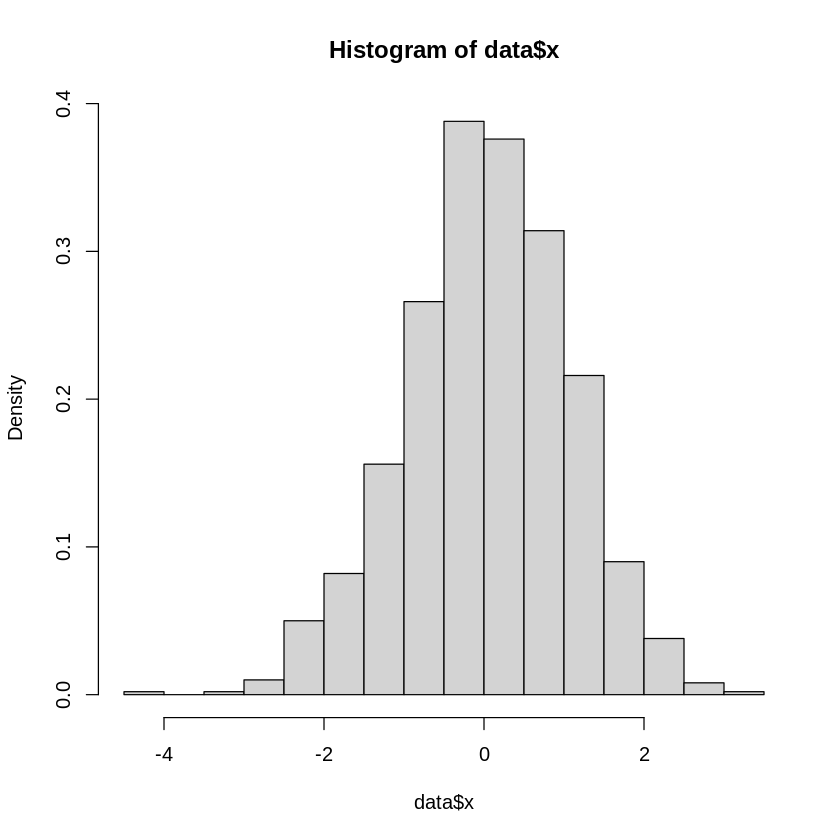

In [16]:
# R base
hist(data$x, freq = F)
# ggplot2


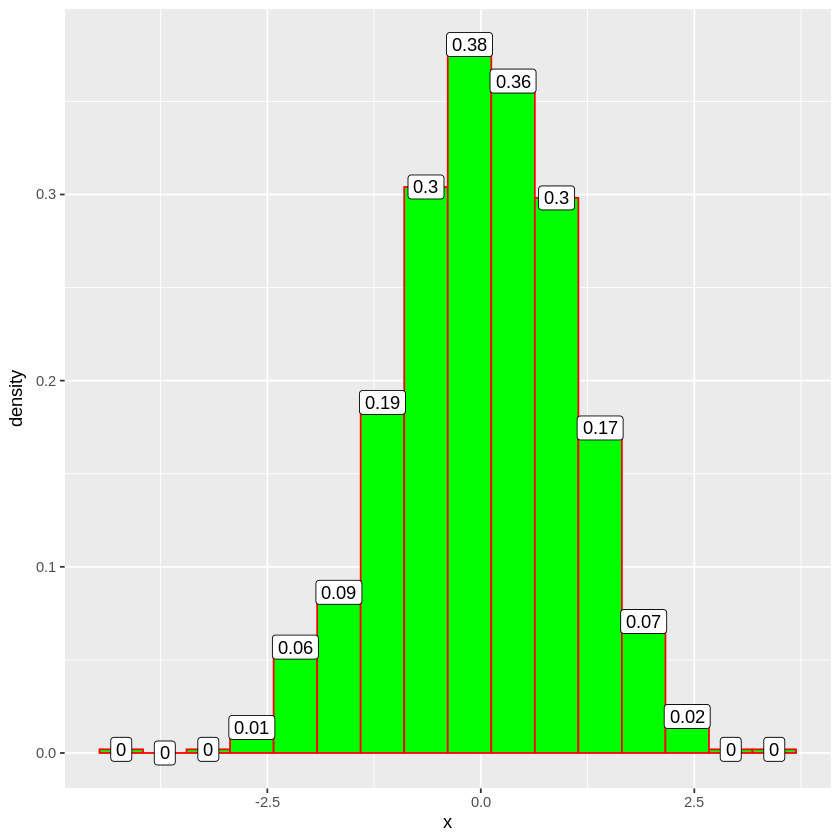

In [19]:
data %>%
  ggplot() +
  aes(x = x, y = after_stat(density)) +
  geom_histogram(
    bins = 16,
    fill = "green",
    color = "red"
  ) +
  stat_bin(
    bins = 16,
    geom = "label",
    mapping = aes(label = round(after_stat(density),2) )
  )

## `theme()`: Permite modificar diversos parámetros gráficos, en particualar la orientación de los ejes.

En este ejemplo consideraremos la data de vuelos, para lo cual buscaremos visualizar la serie que contiene el total de vuelos por cada día.
Adicionalmente modificaremos la orientación de las etiquetas del eje X mediante la función `theme()`.

In [20]:
# Orientación etiquetas ejes ----------------------------------------------
data(flights)

# A modo de ejemplo podemos visulizar el total de vuelos por día .
# Primero podemos generar est resumen de vuelos en un df


In [21]:
head(flights)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00


In [24]:
# Resumen con total de vuelos por día.
resumen <- flights %>%
  mutate(fecha = as.Date(time_hour)) %>%
  group_by(fecha) %>%
  summarise(total_vuelos = n())

In [28]:
resumen2 <- flights %>%
  mutate(fecha = as.Date(time_hour)) %>%
  count(fecha)

In [29]:
head(resumen2)

fecha,n
<date>,<int>
2013-01-01,709
2013-01-02,930
2013-01-03,917
2013-01-04,917
2013-01-05,768
2013-01-06,784


In [25]:
head(resumen)

fecha,total_vuelos
<date>,<int>
2013-01-01,709
2013-01-02,930
2013-01-03,917
2013-01-04,917
2013-01-05,768
2013-01-06,784


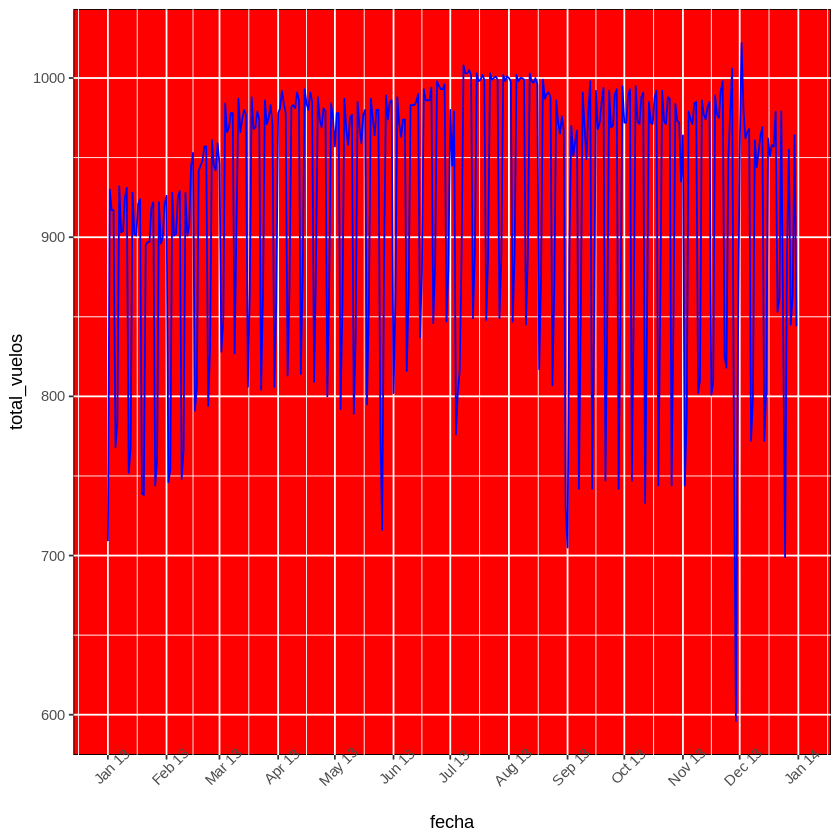

In [35]:

# La función element_text() permite modificar orientación, y ajste vertical y hoizontal

resumen %>%
  filter(fecha <= "2013-12-31") %>%
  ggplot() +
  aes(x = fecha, y = total_vuelos) %>%
  geom_line(col = "blue") +
  theme(panel.background = element_rect(fill = "red",color = "black"),
        axis.text.x = element_text(angle = 45)) +
  scale_x_date(date_breaks =  "1 month", date_labels = "%b %y")


In [36]:
?element_rect

In [32]:
?theme

## `geom_bar()`, `geom_label()`: Al igual que `geom_text()`, permite añadir etiquetas en la visualización, sin la necesidad de generar manualmente los bins.

 1. Construir un gráfico de barras con el total de vuelos por cada carrier.



In [37]:
data(flights)

In [40]:
vuelos_por_carrier <- flights %>%
  count(carrier)

In [41]:
head(vuelos_por_carrier)

carrier,n
<chr>,<int>
9E,18460
AA,32729
AS,714
B6,54635
DL,48110
EV,54173


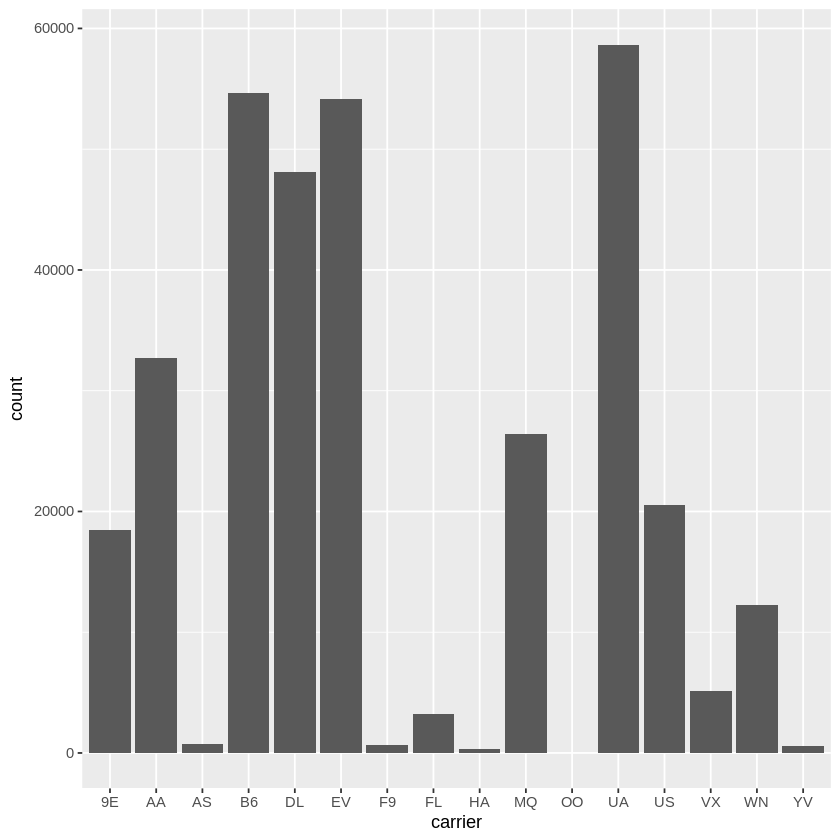

In [39]:
# Opción 1: Dejando que geom_bar saque las cuentas...
flights %>%
  ggplot() +
  aes(x = carrier) +
  geom_bar()

 2. Construir un gráfico de barras con el total de vuelos por cada carrier, pero considerando un dataframe con los conteos ya calculados.


In [43]:
head(vuelos_por_carrier)

carrier,n
<chr>,<int>
9E,18460
AA,32729
AS,714
B6,54635
DL,48110
EV,54173


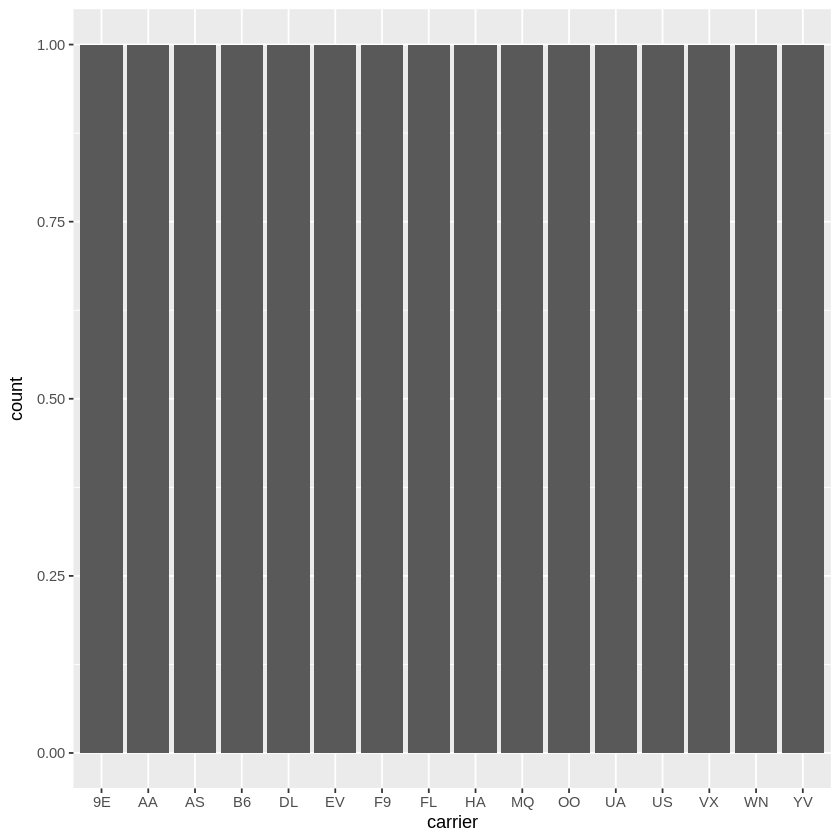

In [42]:
vuelos_por_carrier %>%
  ggplot() +
  aes(x = carrier) +
  geom_bar()

In [46]:
g1 <- vuelos_por_carrier %>%
  ggplot() +
  aes(x = carrier, y = n) +
  geom_bar(stat = "identity" )

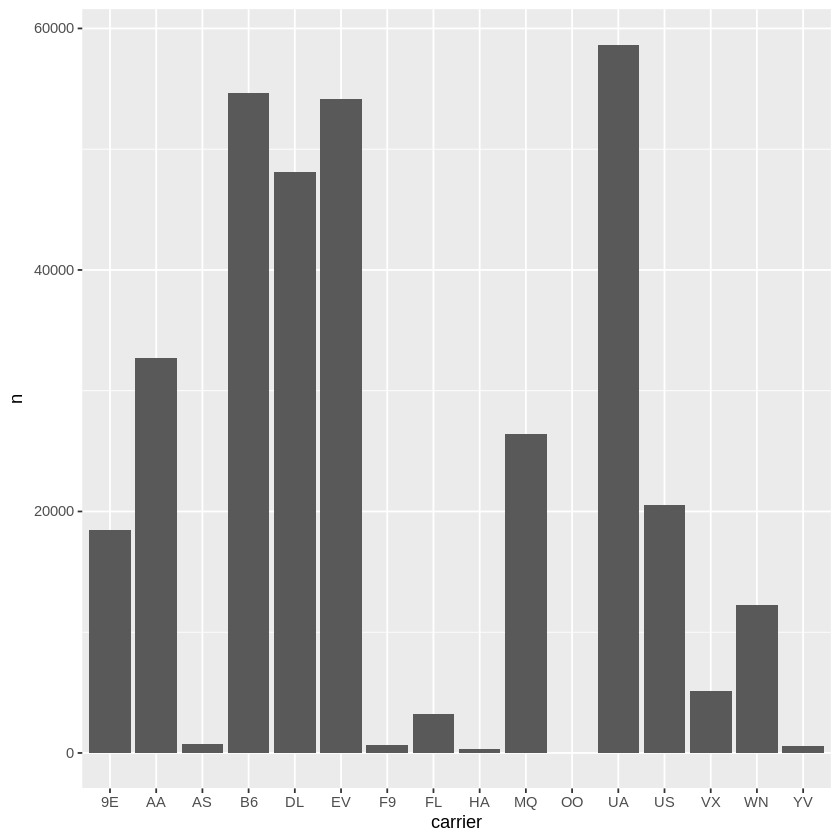

In [47]:
g1

3. Añada etiquetas con los totales de vuelos en cada barra

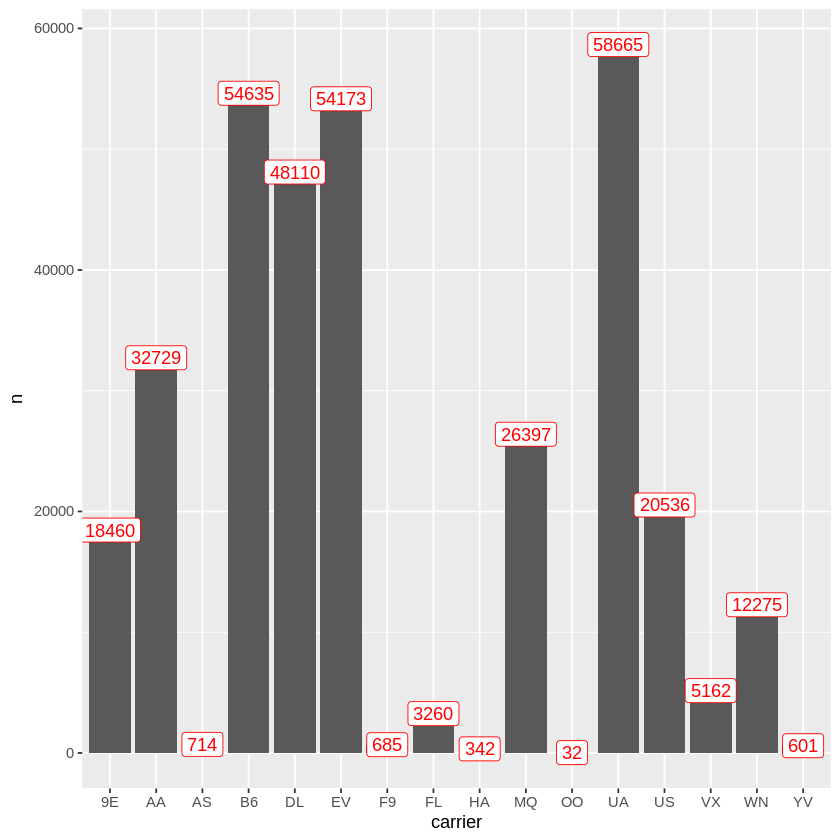

In [50]:
g1 +
  geom_label(mapping = aes(label = n), col = "red")

In [ ]:
# Contamos con las capas geom_label y geom_text ---------------------------------
# Para ello visualizaremos los 4 aeropuertos de destino con mayor cantidad de vuelos, por cada aeropuerto de origen


# conteo por origen destino -----------------------------------------------------


# 4 aeropuertos de destino, con mayor cantidad de vuelos por cada origen --------


 4. Considere un gráfico con los totales de vuelos por aeropuerto de destino, pero solo muestre aeropuertos de destino de ranking 1, 10 y 20 (según su cantidad de vuelos, donde 1 representa al aeropuerto de destino con mayor cantidad de vuelos).

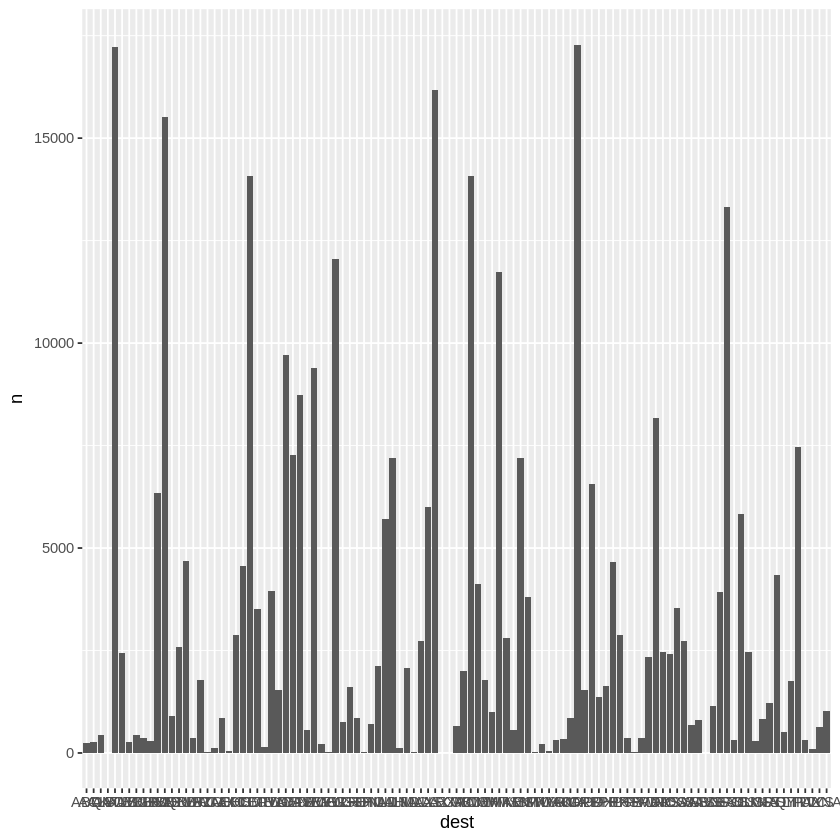

In [51]:
#Considere un gráfico con los totales de vuelos por aeropuerto de destino
flights %>%
  count(dest) %>%
  ggplot() +
  aes(x = dest, y = n) +
  geom_bar(stat = "identity" )

In [52]:
vuelos_por_dest <- flights %>%
  count(dest)

In [57]:
vuelos_por_dest <- vuelos_por_dest %>%
  arrange(desc(n)) %>%
  mutate(rk1 = row_number()) %>% # Opción 1: sólo sirve si la data está ordenada.
  mutate(rk2 = dense_rank(desc(n))) # Opción 2: genera un rankind "denso" sin gaps. (ver documentación)


In [59]:
head(vuelos_por_dest)

dest,n,rk1,rk2
<chr>,<int>,<int>,<int>
ORD,17283,1,1
ATL,17215,2,2
LAX,16174,3,3
BOS,15508,4,4
MCO,14082,5,5
CLT,14064,6,6


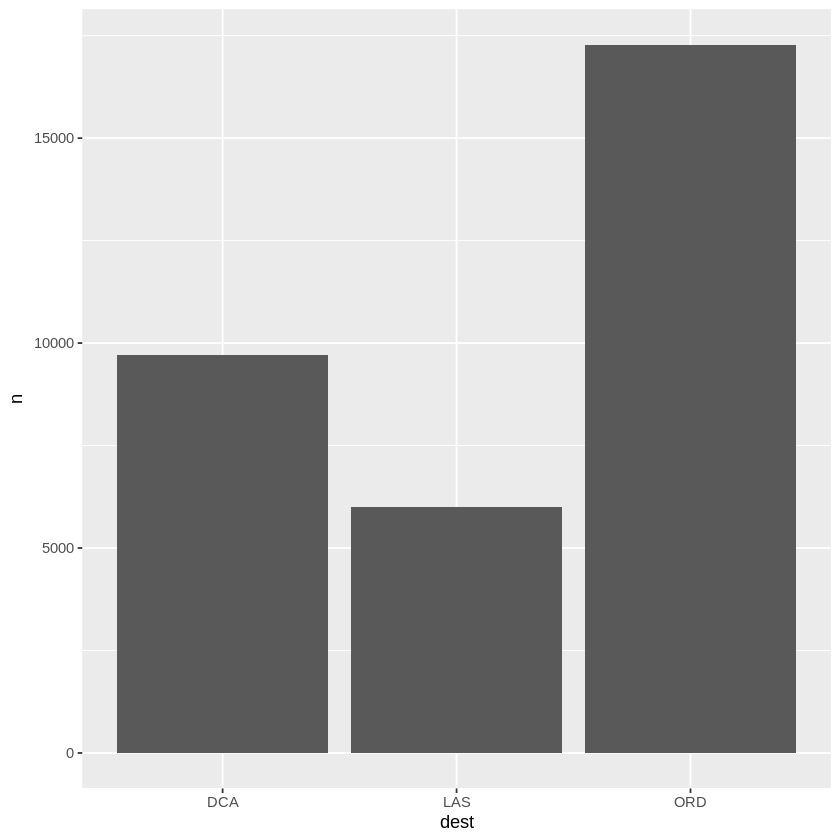

In [62]:
# solo muestre aeropuertos de destino de ranking 1, 10 y 20 (según su cantidad de vuelos, donde 1 representa al aeropuerto de destino con mayor cantidad de vuelos).
vuelos_por_dest %>%
  filter(rk1 %in% c(1,10,20))  %>%
  ggplot() +
  aes(x = dest, y = n) +
  geom_bar(stat = "identity" )

 5. Para los aeropuertos identificados en el punto dos, construir un gráfico de barras stackeado (stacked barchart) que muestre el total de vuelos por aeropuerto de origen.

In [63]:
vuelos_por_dest %>%
  filter(dest =="DCA")

dest,n,rk1,rk2
<chr>,<int>,<int>,<int>
DCA,9705,10,10


In [68]:
vuelos_por_dest %>%
  filter(dest == "ATL")

dest,n,rk1,rk2
<chr>,<int>,<int>,<int>
ATL,17215,2,2


In [86]:
#Opción 1: Cruzando con los totales por destino
resumen_aux1 <-  flights %>%
  count(origin, dest, name = "total_ori_dest") %>%
  arrange(dest) %>% #opcional para ver bien la estructura de la tabla
  left_join(vuelos_por_dest, by = "dest") %>%
  rename(total_dest = n)

In [85]:
#Opción 2: generando un nuevo ranking
resumen_aux2 <- flights %>%
  #count(origin, dest, name = "total_ori_dest") %>%
  group_by(origin, dest) %>%
  summarise(total_ori_dest = n()) %>%
  arrange(dest) %>% # opcional...
  group_by(dest) %>%
  mutate(total_dest = sum(total_ori_dest)) %>%
  ungroup() %>%
  mutate(rk = dense_rank(desc(total_dest))) %>%
  arrange(rk)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by origin and dest.
ℹ Output is grouped by origin.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(origin, dest))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [88]:
resumen_aux1 %>%
  filter(dest == "ATL")

resumen_aux2 %>%
  filter(dest == "ATL")

origin,dest,total_ori_dest,total_dest,rk1,rk2
<chr>,<chr>,<int>,<int>,<int>,<int>
EWR,ATL,5022,17215,2,2
JFK,ATL,1930,17215,2,2
LGA,ATL,10263,17215,2,2


origin,dest,total_ori_dest,total_dest,rk
<chr>,<chr>,<int>,<int>,<int>
EWR,ATL,5022,17215,2
JFK,ATL,1930,17215,2
LGA,ATL,10263,17215,2


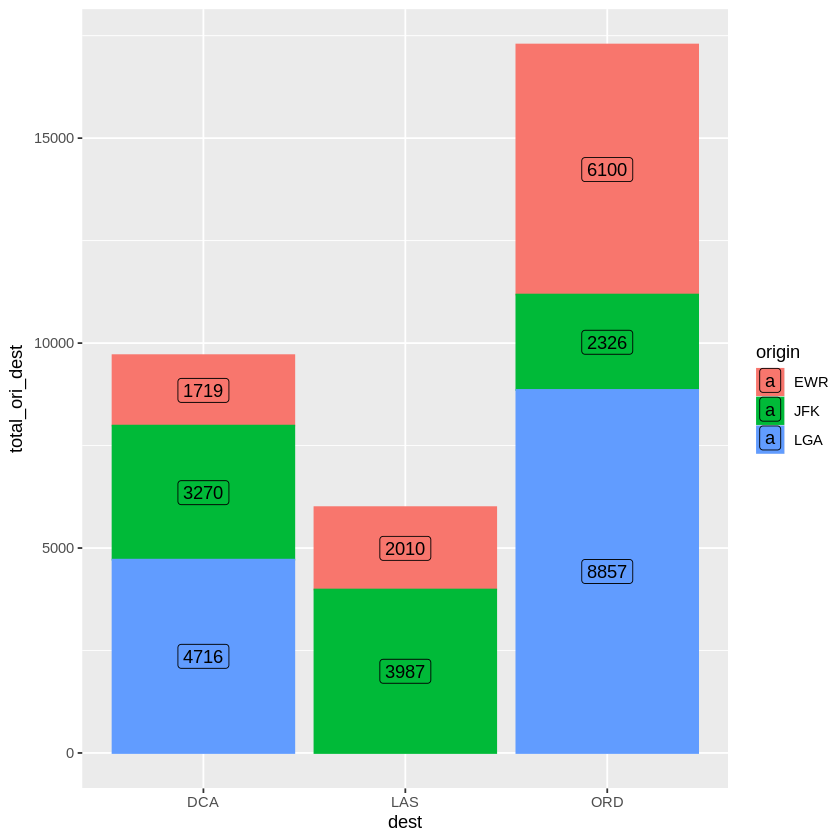

In [93]:
# Stacked bar plot
resumen_aux1 %>%
  filter(rk1 %in% c(1,10,20)) %>%
  ggplot() +
  aes(x = dest, y = total_ori_dest, color = origin, fill = origin) +
  geom_bar(stat = "identity") + # Por defecto al aperturar por color = origin, el gráfico es "stacked"
  geom_label(mapping = aes(label = total_ori_dest),color = "black", position = position_stack(vjust = 0.5))

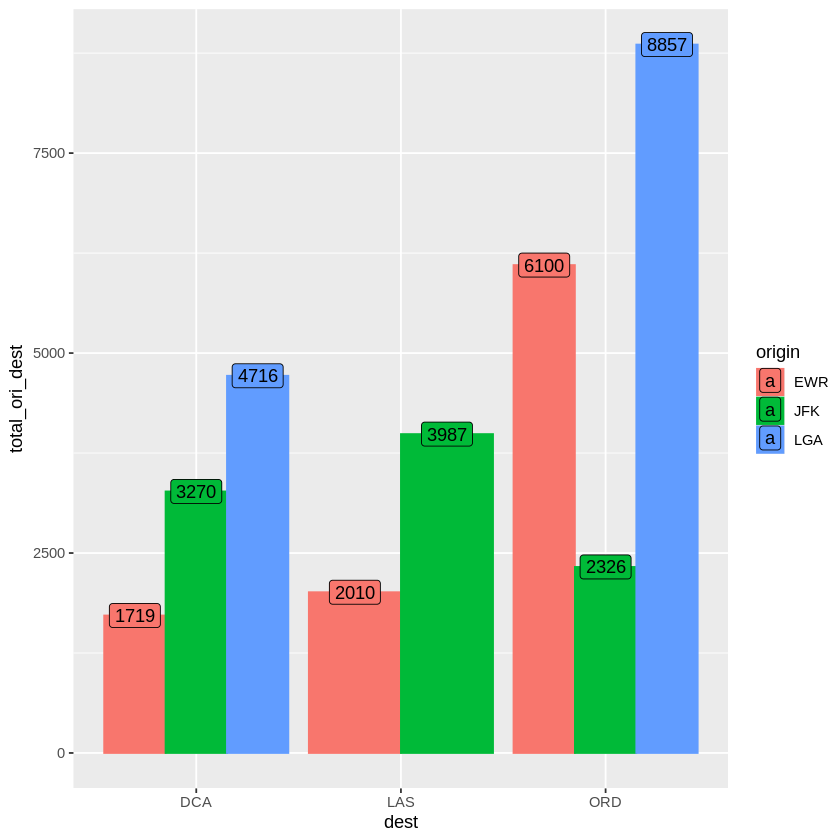

In [97]:
# Dodge bar plot
resumen_aux1 %>%
  filter(rk1 %in% c(1,10,20)) %>%
  ggplot() +
  aes(x = dest, y = total_ori_dest, color = origin, fill = origin) +
  geom_bar(stat = "identity", position = "dodge") + # Por defecto al aperturar por color = origin, el gráfico es "stacked"
  geom_label(mapping = aes(label = total_ori_dest),color = "black", position = position_dodge(width = 0.9))